<a href="https://colab.research.google.com/github/rolandoteniya/walmart-sales-analytics/blob/main/walmart_sales_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

the 5 questions to answer
1. which stores generate the most sales?
2. how do sales change over time?
3. do holidays affect sales?
4. is there a relationship between temperature/fuel prices and sales?
5. which stores have the most volatile sales?

process to answer the questions
1. define business objectives
2. load the data
3. data cleaning
4. exploratory data analysis
5. define/refine the 5 business questions
6. answer questions using sql
8. answer/deepen questions using python
8. visualise findings
9. interpret the resutls
10. business recommendations
11. present the findings

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/After Masters Life/DA DS SOLO PROJECTS/Walmart Sales/Walmart_Sales.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
df.shape #tells you rows x columns
df.info() #tells num of each col and type of each col

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


thing to note. date is an object so will need to change to datetime

In [3]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


thing to note. std of weekly sales is $564k compared to mean of $1.047M. thefore seems to be large variation in weekly sales

mean is higher than median for weekly sales meaning that some high sales are pulling avg up

In [4]:
df.isnull().sum()
df.duplicated().sum()
df['Store'].nunique()

45

In [5]:
df['Date'].min(), df['Date'].max()

('01-04-2011', '31-12-2010')

In [6]:
df['Holiday_Flag'].value_counts()

,count
Holiday_Flag,
0,5985
1,450


In [7]:
# converting date from object to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [8]:
df['Date'].min(), df['Date'].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [9]:
#checking if all stores have the same number of unique weeks
df.groupby('Store')['Date'].nunique().describe()

,Date
count,45.0
mean,143.0
std,0.0
min,143.0
25%,143.0
50%,143.0
75%,143.0
max,143.0


,0
Weekly_Sales,"Axes(0.125,0.11;0.133621x0.77)"
Temperature,"Axes(0.285345,0.11;0.133621x0.77)"
Fuel_Price,"Axes(0.44569,0.11;0.133621x0.77)"
CPI,"Axes(0.606034,0.11;0.133621x0.77)"
Unemployment,"Axes(0.766379,0.11;0.133621x0.77)"


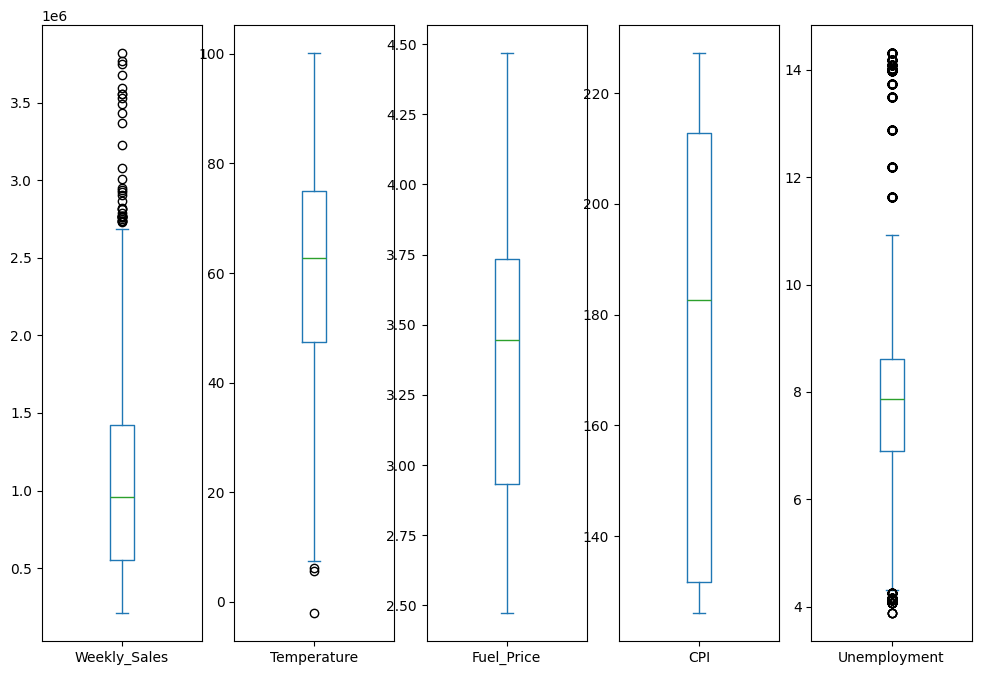

In [10]:
# looking at numerical distributions of each col
df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].plot(
    kind = 'box',
    subplots = True,
    figsize =(12,8)
)

weekly sales: large spread, many potential high end outliers, worth investigating

temp worth investigating

fuel price looks calm

cpi looks calm

unemployment has many observations beyond whisker, meaning distribution is unsual
values of 4% to 11% are actually plausible economically so don't have to be automatically errors.

In [11]:
#Exploratory Data Analysis
#what's the data telling us?
import matplotlib.pyplot as plt

"""1. univariate analysis (sales distribution, num of stores, holiday vs non-holiday, temp, fuel, cpi, unemployment)
2. time analysis (how sales change over time, monthly/seasonal patterns)
3. store analysis (which stores perform best/worst, how consistent each store is)
4. relationship analysis (sales v holidays, sales v temp, sales v fuel, sales v cpi/unemployment)
5. identify interesting findings (help formulate actual business questions)"""

'1. univariate analysis (sales distribution, num of stores, holiday vs non-holiday, temp, fuel, cpi, unemployment)\n2. time analysis (how sales change over time, monthly/seasonal patterns)\n3. store analysis (which stores perform best/worst, how consistent each store is)\n4. relationship analysis (sales v holidays, sales v temp, sales v fuel, sales v cpi/unemployment)\n5. identify interesting findings (help formulate actual business questions)'

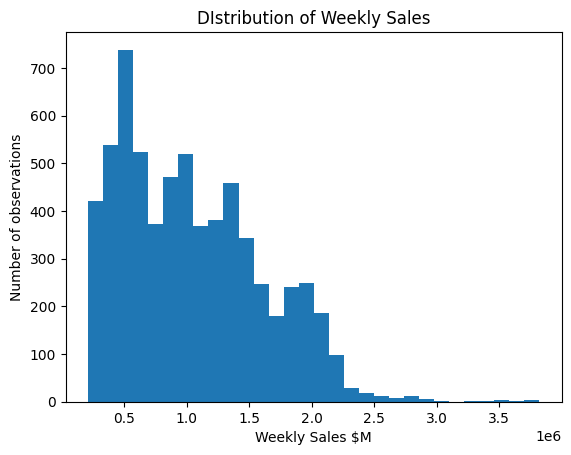

In [12]:
#weekly sales distribution
plt.hist(df['Weekly_Sales'], bins=30) #bins is the num of categories shown in the histogram
plt.xlabel('Weekly Sales $M')
plt.ylabel('Number of observations')
plt.title('DIstribution of Weekly Sales')
plt.show()

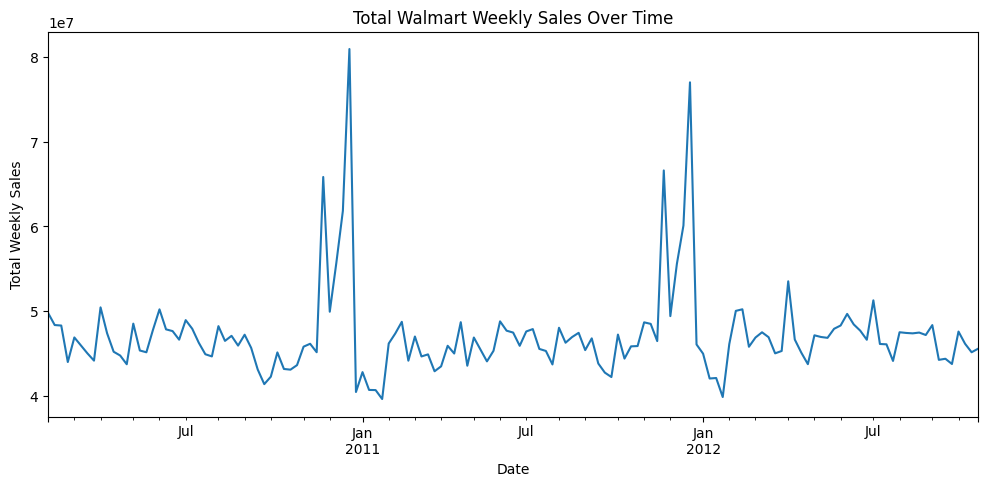

In [13]:
#sales over time
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

weekly_sales.plot(figsize=(12, 5))
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.title('Total Walmart Weekly Sales Over Time')
plt.show()

In [14]:
#store performance
store_sales = df.groupby('Store')['Weekly_Sales'].agg(['mean', 'sum', 'std'])
store_sales.sort_values('mean', ascending=False).head(10)

,mean,sum,std
Store,,,
20,2.107677e+06,3.013978e+08,275900.562742
4,2.094713e+06,2.995440e+08,266201.442297
14,2.020978e+06,2.889999e+08,317569.949476
13,2.003620e+06,2.865177e+08,265506.995776
2,1.925751e+06,2.753824e+08,237683.694682
10,1.899425e+06,2.716177e+08,302262.062504
27,1.775216e+06,2.538559e+08,239930.135688
6,1.564728e+06,2.237561e+08,212525.855862
1,1.555264e+06,2.224028e+08,155980.767761


### Finding higest mean
Store 20 has the highest average weekly sales and total sales across the dataset.

Store 20, 4, 14, 13 are over 2m mean and Store 2, 10 are 1.9m mean.
### Potential question
What makes Store 20 outperform the other stores?

In [15]:
store_sales.sort_values('std', ascending=False).head(10)

,mean,sum,std
Store,,,
14,2.020978e+06,2.889999e+08,317569.949476
10,1.899425e+06,2.716177e+08,302262.062504
20,2.107677e+06,3.013978e+08,275900.562742
4,2.094713e+06,2.995440e+08,266201.442297
13,2.003620e+06,2.865177e+08,265506.995776
23,1.389864e+06,1.987506e+08,249788.038068
27,1.775216e+06,2.538559e+08,239930.135688
2,1.925751e+06,2.753824e+08,237683.694682
39,1.450668e+06,2.074455e+08,217466.454833


### Finding highest std
Store 14 is highest with 318k, store 10 close second with 302k.

###Potential question
What makes these stores so volatile?

In [16]:
store_sales.sort_values('mean', ascending=True).head(10)

,mean,sum,std
Store,,,
33,259861.692028,37160221.96,24132.927322
44,302748.866014,43293087.84,24762.832015
5,318011.810490,45475688.90,37737.965745
36,373511.992797,53412214.97,60725.173579
38,385731.653287,55159626.42,42768.169450
3,402704.441049,57586735.07,46319.631557
30,438579.616224,62716885.12,22809.665590
37,518900.281958,74202740.32,21837.461190
16,519247.730070,74252425.40,85769.680133


### Findings lowest mean
Store 33 has mean of 260k by far lowest. store 44, 5, 36 and 38 all have mean lower than 400k

### potential question
why are they selling so low?

In [17]:
store_sales.sort_values('std', ascending=True).head(10)

,mean,sum,std
Store,,,
37,518900.281958,74202740.32,21837.461190
30,438579.616224,62716885.12,22809.665590
33,259861.692028,37160221.96,24132.927322
44,302748.866014,43293087.84,24762.832015
5,318011.810490,45475688.90,37737.965745
43,633324.723147,90565435.41,40598.413260
38,385731.653287,55159626.42,42768.169450
3,402704.441049,57586735.07,46319.631557
42,556403.863147,79565752.43,50262.925530


### Findings lowest std
Store 37 - 21.8k std, lowest (most consistent store)
Store 30, 33, 44 - all sub 30k std

### Potential questions
Why don't they experience much change?

In [18]:
#Holiday vs non-holiday stores
# df[df['Holiday_Flag'] == 1]['Date'].unique()

df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean', 'sum', 'std', 'count'])


,mean,sum,std,count
Holiday_Flag,,,,
0,1.041256e+06,6.231919e+09,558957.436147,5985
1,1.122888e+06,5.052996e+08,627684.931884,450


holiday weeks have slightly higher mean than non-holiday. 1.12m compared to 1.04m.

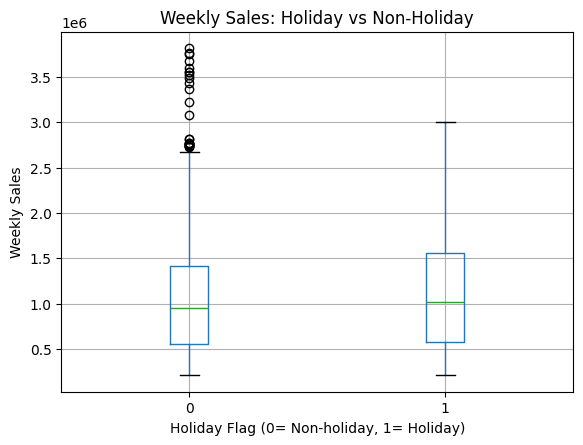

In [19]:
df.boxplot(column='Weekly_Sales', by='Holiday_Flag')
plt.title('Weekly Sales: Holiday vs Non-Holiday')
plt.suptitle('')
plt.xlabel('Holiday Flag (0= Non-holiday, 1= Holiday)')
plt.ylabel('Weekly Sales')
plt.show()

### Findings
non holiday mean similar for both
non holiday has a lot of outlier points over max from 2.75 up to 3.8.



In [20]:
#HOLIDAY V NON HOLIDAY SALES FOR EACH STORE
holiday_store = df.groupby(['Store', 'Holiday_Flag'])['Weekly_Sales'].mean().unstack()
holiday_store

Holiday_Flag,0,1
Store,,
1,1.546957e+06,1665747.656
2,1.914209e+06,2079266.900
3,4.000648e+05,437811.050
4,2.083556e+06,2243102.624
5,3.148923e+05,359501.607
6,1.555993e+06,1680907.927
7,5.629645e+05,672400.265
8,9.037434e+05,975330.860
9,5.405993e+05,588950.821


In [22]:
holiday_store['Holiday_Change_%'] = ((holiday_store[1] - holiday_store[0])/ holiday_store[0] * 100)

holiday_store.sort_values('Holiday_Change_%', ascending = False)

Holiday_Flag,0,1,Holiday_Change_%
Store,,,
7,5.629645e+05,672400.265,19.439204
35,9.080992e+05,1074348.457,18.307395
15,6.170648e+05,706406.018,14.478410
5,3.148923e+05,359501.607,14.166537
12,9.992919e+05,1138140.420,13.894688
29,5.343758e+05,606957.889,13.582602
28,1.311889e+06,1478244.605,12.680617
10,1.883309e+06,2113755.949,12.236254
17,8.870990e+05,979796.971,10.449561


store 7 and 35 are the highest changing with 19.4% and 18.3% respectively. there are a lot of stores that have positive changes in fact, all but 5 have positive changes. they are roughly distributed equally from 0 to 14% store 44 and 37 are lowest with -2.38% and -2.35% respectively and stores 36, 38, 30 are all negative.

Holiday weeks are associated with higher sales across the majority of stores, although the magnitude varies considerably between stores.

In [24]:
#percentage change on holiday vs non holiday weekly sales vs avg sales

store_avg = df.groupby('Store')['Weekly_Sales'].mean()
holiday_store['Average_Sales'] = store_avg

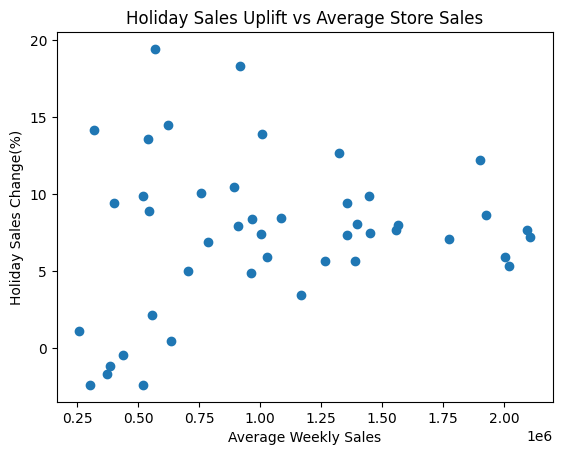

In [28]:
plt.scatter(
    holiday_store['Average_Sales'],
    holiday_store['Holiday_Change_%']
)

plt.xlabel('Average Weekly Sales')
plt.ylabel('Holiday Sales Change(%)')
plt.title('Holiday Sales Uplift vs Average Store Sales')
plt.show()

there's no apparent trend tbf. the only trend i'd say there is it's that most, about 75% ish of points are roughly within 5-15% holiday sales change %. i'd also say that majority of sales that are not within that bracket are in stores which are lower than 1mil weekly sales. in fact all of them are. 2 above that and 8 below